# PhiUSIIL Phishing URL Dataset — Aleph ILP

This notebook uses the same lab-style Aleph workflow used in the module exercises:

```python
from PyILP.PyILP import *
model = aleph_learn(...)
```

The dataset is transformed into symbolic Prolog facts, Aleph learns rules from positive and negative examples, and the learned rules are evaluated on a held-out test set.

The notebook expects these files in the same folder as the notebook:

```text
PhiUSIIL_Phishing_URL_Dataset.csv
aleph.pl
```

The main result file is saved to:

```text
outputs/aleph_phiusiil/aleph_phiusiil_results.csv
```

This is the path expected by `05_evaluate_thread2_phiusiil.ipynb`.

The Aleph output CSV now includes `train_roc_auc` and `test_roc_auc`. Since Aleph gives hard logical predictions rather than probabilities, this ROC-AUC is calculated from the hard prediction operating point, equivalent to balanced accuracy.


In [1]:
# ==============================
# Cell 0: Environment and folders
# ==============================

from pathlib import Path
import os
import sys
import shutil
import warnings
warnings.filterwarnings("ignore")

# Run the notebook from the PhiUSIIL folder.
# This keeps the code portable and avoids hard-coded personal paths.
BASE_DIR = Path.cwd()

DATA_PATH = BASE_DIR / "PhiUSIIL_Phishing_URL_Dataset.csv"
ALEPH_SOURCE = BASE_DIR / "aleph.pl"

ALEPH_DIR = BASE_DIR / "aleph_files"
OUTPUT_DIR = BASE_DIR / "outputs" / "aleph_phiusiil"
ALEPH_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python executable:", sys.executable)
print("Working folder:", BASE_DIR)
print("Dataset exists:", DATA_PATH.exists(), DATA_PATH)
print("aleph.pl exists:", ALEPH_SOURCE.exists(), ALEPH_SOURCE)
print("Aleph outputs folder:", OUTPUT_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError("Put PhiUSIIL_Phishing_URL_Dataset.csv in the same folder as this notebook.")

if not ALEPH_SOURCE.exists():
    raise FileNotFoundError("Put your lab aleph.pl file in the same folder as this notebook.")

from PyILP.PyILP import *
import PyILP.PyILP as pyilp_module

print("PyILP imported successfully.")

Python executable: C:\Users\rahin\Documents\Masters Course\ML for DS\week 8\venv\Scripts\python.exe
Working folder: C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp
Dataset exists: True C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\PhiUSIIL_Phishing_URL_Dataset.csv
aleph.pl exists: True C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\aleph.pl
Aleph outputs folder: C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\outputs\aleph_phiusiil
PyILP imported successfully.


In [2]:
# ==============================
# Cell 1: Load the dataset
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset shape:", df_raw.shape)
print("Columns:")
print(df_raw.columns.tolist())

print("\nLabel distribution:")
print(df_raw["label"].value_counts(dropna=False))

# A small manual check of URLs helps confirm the label interpretation.
if "URL" in df_raw.columns:
    print("\nExample URLs by label:")
    display(df_raw.groupby("label")[["URL"]].head(5))

Dataset shape: (235795, 56)
Columns:
['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']

Label distribution:
label
1    134850
0    

,URL
0,https://www.southbankmosaics.com
1,https://www.uni-mainz.de
2,https://www.voicefmradio.co.uk
3,https://www.sfnmjournal.com
4,https://www.rewildingargentina.org
11,http://www.teramill.com
20,http://www.f0519141.xsph.ru
21,http://www.shprakserf.gq
27,https://service-mitld.firebaseapp.com/
28,http://www.kuradox92.lima-city.de


In [3]:
# ==============================
# Cell 2: Clean data and define target
# ==============================

df = df_raw.copy()

TARGET_COL = "label"

# From manual inspection, label 0 corresponds to phishing-like URLs
# and label 1 corresponds to legitimate-looking URLs.
PHISHING_LABEL = 0

df = df.dropna(subset=[TARGET_COL]).copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)

# Aleph will learn phishing(A), so positive examples are phishing URLs.
df["is_phishing"] = (df[TARGET_COL] == PHISHING_LABEL).astype(int)

# Raw text fields are not used directly in Aleph here.
# The dataset already includes numeric URL and webpage features.
TEXT_OR_ID_COLS = ["FILENAME", "URL", "Domain", "Title", "TLD"]

candidate_features = [
    c for c in df.columns
    if c not in TEXT_OR_ID_COLS + [TARGET_COL, "is_phishing"]
    and pd.api.types.is_numeric_dtype(df[c])
]

# Median imputation keeps the symbolic conversion stable.
for c in candidate_features:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

print("Number of numeric candidate features:", len(candidate_features))
print(candidate_features)

print("\nTarget distribution used by Aleph:")
print(df["is_phishing"].value_counts())
print("\n1 = phishing, 0 = legitimate")

Number of numeric candidate features: 50
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']

Target distribution used by Aleph:
is_phishing
0    134850
1    100945
Name: count, dtype: in

Missing values after cleaning:


URLLength               0
DomainLength            0
IsDomainIP              0
URLSimilarityIndex      0
CharContinuationRate    0
TLDLegitimateProb       0
URLCharProb             0
TLDLength               0
NoOfSubDomain           0
HasObfuscation          0
NoOfObfuscatedChar      0
ObfuscationRatio        0
NoOfLettersInURL        0
LetterRatioInURL        0
NoOfDegitsInURL         0
dtype: int64


IsHTTPS


IsHTTPS,0,1
is_phishing,,
0,0.000000,1.000000
1,0.507762,0.492238



URLSimilarityIndex


...

,count,mean,std,min,25%,50%,75%,max
is_phishing,,,,,,,,
0,134850.0,44.946600,100.930539,0.0,13.0,25.0,47.0,8956.0
1,100945.0,0.866492,3.296497,0.0,0.0,0.0,0.0,158.0



NoOfOtherSpecialCharsInURL


,count,mean,std,min,25%,50%,75%,max
is_phishing,,,,,,,,
0,134850.0,1.244835,0.503961,0.0,1.0,1.0,1.0,7.0
1,100945.0,3.803467,4.998448,1.0,2.0,3.0,5.0,499.0



NoOfJS


,count,mean,std,min,25%,50%,75%,max
is_phishing,,,,,,,,
0,134850.0,17.732532,27.213939,0.0,8.0,14.0,23.0,6957.0
1,100945.0,0.890336,3.362975,0.0,0.0,0.0,0.0,102.0


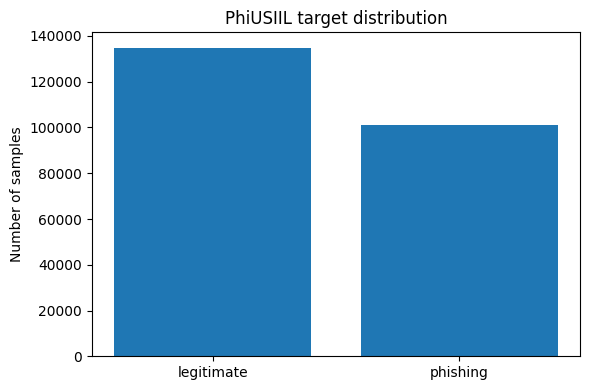

In [4]:
# ==============================
# Cell 3: Small EDA for the Aleph section
# ==============================

print("Missing values after cleaning:")
display(df[candidate_features + ["is_phishing"]].isna().sum().sort_values(ascending=False).head(15))

diagnostic_features = [
    "IsHTTPS",
    "URLSimilarityIndex",
    "HasDescription",
    "HasCopyrightInfo",
    "NoOfImage",
    "NoOfOtherSpecialCharsInURL",
    "NoOfJS"
]

for col in diagnostic_features:
    if col in df.columns:
        print("\n" + "=" * 70)
        print(col)
        print("=" * 70)

        if df[col].nunique() <= 10:
            display(pd.crosstab(df["is_phishing"], df[col], normalize="index"))
        else:
            display(df.groupby("is_phishing")[col].describe())

plt.figure(figsize=(6, 4))
counts = df["is_phishing"].value_counts().sort_index()
plt.bar(["legitimate", "phishing"], counts.values)
plt.title("PhiUSIIL target distribution")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aleph_target_distribution.png", dpi=300)
plt.show()

In [5]:
# ==============================
# Cell 4: Balanced ILP sample
# ==============================

# Aleph is a symbolic learner and can be slow on very large datasets.
# A balanced sample makes rule learning feasible and keeps the positive/negative classes equal.
ILP_SAMPLES_PER_CLASS = 500

df_phish = df[df["is_phishing"] == 1]
df_legit = df[df["is_phishing"] == 0]

n_per_class = min(ILP_SAMPLES_PER_CLASS, len(df_phish), len(df_legit))

df_ilp = pd.concat([
    df_phish.sample(n=n_per_class, random_state=42),
    df_legit.sample(n=n_per_class, random_state=42)
], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print("ILP sample shape:", df_ilp.shape)
print(df_ilp["is_phishing"].value_counts())

ILP sample shape: (1000, 57)
is_phishing
0    500
1    500
Name: count, dtype: int64


In [6]:
# ==============================
# Cell 5: Train/test split and feature selection
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

train_df, test_df = train_test_split(
    df_ilp,
    test_size=0.30,
    random_state=42,
    stratify=df_ilp["is_phishing"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Prolog identifiers must be simple atoms.
train_df["uid"] = [f"tr{i:05d}" for i in range(len(train_df))]
test_df["uid"] = [f"te{i:05d}" for i in range(len(test_df))]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain class balance:")
print(train_df["is_phishing"].value_counts())
print("\nTest class balance:")
print(test_df["is_phishing"].value_counts())

# Feature selection is done only on training data to avoid test leakage.
MAX_ILP_FEATURES = 20

mi_scores = mutual_info_classif(
    train_df[candidate_features],
    train_df["is_phishing"],
    random_state=42
)

feature_scores = pd.DataFrame({
    "feature": candidate_features,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

selected_features = feature_scores.head(MAX_ILP_FEATURES)["feature"].tolist()

feature_scores.to_csv(OUTPUT_DIR / "aleph_feature_scores.csv", index=False)

print("Selected Aleph features:")
print(selected_features)

display(feature_scores.head(30))

Train shape: (700, 58)
Test shape: (300, 58)

Train class balance:
is_phishing
1    350
0    350
Name: count, dtype: int64

Test class balance:
is_phishing
1    150
0    150
Name: count, dtype: int64
Selected Aleph features:
['URLSimilarityIndex', 'LineOfCode', 'NoOfExternalRef', 'NoOfImage', 'NoOfSelfRef', 'NoOfJS', 'NoOfCSS', 'LargestLineLength', 'LetterRatioInURL', 'HasSocialNet', 'HasCopyrightInfo', 'HasDescription', 'IsHTTPS', 'HasSubmitButton', 'NoOfOtherSpecialCharsInURL', 'DomainTitleMatchScore', 'NoOfEmptyRef', 'URLTitleMatchScore', 'NoOfiFrame', 'SpacialCharRatioInURL']


,feature,mutual_info
3,URLSimilarityIndex,0.656551
22,LineOfCode,0.594483
49,NoOfExternalRef,0.593928
44,NoOfImage,0.568251
47,NoOfSelfRef,0.528352
46,NoOfJS,0.491068
45,NoOfCSS,0.421299
23,LargestLineLength,0.397028
13,LetterRatioInURL,0.347691
36,HasSocialNet,0.336427


In [7]:
# ==============================
# Cell 6: Convert numeric features into symbolic predicates
# ==============================

import re

def safe_name(name):
    """Make a dataset column name safe for Prolog predicate names."""
    name = str(name).strip().lower()
    name = re.sub(r"[^a-z0-9_]", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    if not name or not name[0].isalpha():
        name = "f_" + name
    return name

feature_map = {c: safe_name(c) for c in selected_features}

feature_types = {}
thresholds = {}

for col in selected_features:
    values = set(float(v) for v in train_df[col].dropna().unique())

    if values.issubset({0.0, 1.0}):
        feature_types[col] = "binary"
    else:
        feature_types[col] = "continuous"
        thresholds[col] = (
            train_df[col].quantile(0.33),
            train_df[col].quantile(0.67)
        )

threshold_rows = []
for col in selected_features:
    threshold_rows.append({
        "feature": col,
        "safe_feature": feature_map[col],
        "type": feature_types[col],
        "low_threshold": thresholds[col][0] if col in thresholds else None,
        "high_threshold": thresholds[col][1] if col in thresholds else None,
    })

thresholds_df = pd.DataFrame(threshold_rows)
thresholds_df.to_csv(OUTPUT_DIR / "aleph_discretisation_thresholds.csv", index=False)

display(thresholds_df)

,feature,safe_feature,type,low_threshold,high_threshold
0,URLSimilarityIndex,urlsimilarityindex,continuous,61.434103,100.00000
1,LineOfCode,lineofcode,continuous,35.000000,766.66000
2,NoOfExternalRef,noofexternalref,continuous,1.000000,21.33000
3,NoOfImage,noofimage,continuous,0.000000,18.00000
4,NoOfSelfRef,noofselfref,continuous,0.000000,47.00000
5,NoOfJS,noofjs,continuous,0.000000,10.00000
6,NoOfCSS,noofcss,continuous,0.000000,4.00000
7,LargestLineLength,largestlinelength,continuous,245.340000,3438.12000
8,LetterRatioInURL,letterratioinurl,continuous,0.480000,0.57199
9,HasSocialNet,hassocialnet,binary,NaN,NaN


In [8]:
# ==============================
# Cell 7: Create Prolog facts
# ==============================

def discretise_value(v, low, high):
    if v <= low:
        return "low"
    elif v <= high:
        return "med"
    else:
        return "high"

def predicate_for_value(col, value):
    safe_col = feature_map[col]

    if feature_types[col] == "binary":
        return f"has_{safe_col}" if int(round(float(value))) == 1 else f"no_{safe_col}"

    low, high = thresholds[col]
    level = discretise_value(value, low, high)
    return f"{level}_{safe_col}"

def make_bg_facts(df_part):
    facts = []

    for _, row in df_part.iterrows():
        uid = row["uid"]

        for col in selected_features:
            pred = predicate_for_value(col, row[col])
            facts.append(f"{pred}({uid}).")

    return facts

# Background knowledge contains features for train and test instances, but not labels.
# Labels are stored only in the positive and negative example files.
all_instances = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
all_bg_facts = make_bg_facts(all_instances)

print("Number of background facts:", len(all_bg_facts))
print("Example facts:")
print("\n".join(all_bg_facts[:20]))

Number of background facts: 20000
Example facts:
med_urlsimilarityindex(tr00000).
low_lineofcode(tr00000).
low_noofexternalref(tr00000).
low_noofimage(tr00000).
low_noofselfref(tr00000).
low_noofjs(tr00000).
low_noofcss(tr00000).
low_largestlinelength(tr00000).
high_letterratioinurl(tr00000).
no_hassocialnet(tr00000).
no_hascopyrightinfo(tr00000).
no_hasdescription(tr00000).
no_ishttps(tr00000).
no_hassubmitbutton(tr00000).
med_noofotherspecialcharsinurl(tr00000).
med_domaintitlematchscore(tr00000).
low_noofemptyref(tr00000).
med_urltitlematchscore(tr00000).
low_noofiframe(tr00000).
high_spacialcharratioinurl(tr00000).


In [9]:
# ==============================
# Cell 8: Write Aleph files in the lab exercise style
# ==============================

import json
import shutil

# This is the same pattern as the lab exercises:
# a background file, a positive example file, and a negative example file.
# aleph.pl is copied into the Aleph working folder and also kept in BASE_DIR.
shutil.copy(ALEPH_SOURCE, ALEPH_DIR / "aleph.pl")

train_pos = train_df[train_df["is_phishing"] == 1]
train_neg = train_df[train_df["is_phishing"] == 0]
test_pos = test_df[test_df["is_phishing"] == 1]
test_neg = test_df[test_df["is_phishing"] == 0]

train_pos_file = ALEPH_DIR / "phishing_train_pos.f"
train_neg_file = ALEPH_DIR / "phishing_train_neg.n"
test_pos_file = ALEPH_DIR / "phishing_test_pos.f"
test_neg_file = ALEPH_DIR / "phishing_test_neg.n"

train_pos_file.write_text("\n".join([f"phishing({uid})." for uid in train_pos["uid"]]), encoding="utf-8")
train_neg_file.write_text("\n".join([f"phishing({uid})." for uid in train_neg["uid"]]), encoding="utf-8")
test_pos_file.write_text("\n".join([f"phishing({uid})." for uid in test_pos["uid"]]), encoding="utf-8")
test_neg_file.write_text("\n".join([f"phishing({uid})." for uid in test_neg["uid"]]), encoding="utf-8")

print("Train positives:", len(train_pos))
print("Train negatives:", len(train_neg))
print("Test positives:", len(test_pos))
print("Test negatives:", len(test_neg))

body_predicates = []

for col in selected_features:
    safe_col = feature_map[col]

    if feature_types[col] == "binary":
        body_predicates.extend([f"has_{safe_col}", f"no_{safe_col}"])
    else:
        body_predicates.extend([f"low_{safe_col}", f"med_{safe_col}", f"high_{safe_col}"])

body_predicates = sorted(set(body_predicates))

print("Number of possible body predicates:", len(body_predicates))

ALEPH_SETTING_GRID = [
    {"name": "i2_minpos5",  "i": 2, "minpos": 5,  "clauselength": 4, "nodes": 5000},
    {"name": "i3_minpos5",  "i": 3, "minpos": 5,  "clauselength": 5, "nodes": 7000},
    {"name": "i4_minpos10", "i": 4, "minpos": 10, "clauselength": 6, "nodes": 10000},
]

def write_aleph_background_file(setting):
    pl_file = ALEPH_DIR / f"phishing_{setting['name']}.pl"

    content = []

    # This line follows the working lab/PyILP style.
    # Because aleph.pl is present in the working folder, Prolog can load induce/1.
    content.append(":- use_module(aleph).")
    content.append(":- aleph.")
    content.append(":- style_check(-discontiguous).")
    content.append(f":- aleph_set(i,{setting['i']}).")
    content.append(f":- aleph_set(minpos,{setting['minpos']}).")
    content.append(f":- aleph_set(clauselength,{setting['clauselength']}).")
    content.append(f":- aleph_set(nodes,{setting['nodes']}).")
    content.append("")
    content.append(":- modeh(1, phishing(+url)).")

    for pred in body_predicates:
        content.append(f":- modeb(1, {pred}(+url)).")

    content.append("")

    for pred in body_predicates:
        content.append(f":- determination(phishing/1, {pred}/1).")

    content.append("")
    content.append(":-begin_bg.")
    content.extend(all_bg_facts)
    content.append(":-end_bg.")
    content.append("")

    pl_file.write_text("\n".join(content), encoding="utf-8")
    return pl_file

setting_files = []
for setting in ALEPH_SETTING_GRID:
    pl_file = write_aleph_background_file(setting)
    setting_files.append({"setting": setting, "pl_file": pl_file})
    print("Wrote:", pl_file, "lines:", len(pl_file.read_text(encoding="utf-8").splitlines()))

config = {
    "target": "phishing/1",
    "phishing_label": int(PHISHING_LABEL),
    "samples_per_class": int(n_per_class),
    "selected_features": selected_features,
    "feature_types": feature_types,
    "setting_grid": ALEPH_SETTING_GRID,
}

with open(OUTPUT_DIR / "aleph_run_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

# Quick check that the generated file is complete.
sample_file = setting_files[0]["pl_file"]
print("\nFirst 15 lines of the first Aleph file:")
for i, line in enumerate(sample_file.read_text(encoding="utf-8").splitlines()[:15], start=1):
    print(f"{i}: {line}")

Train positives: 350
Train negatives: 350
Test positives: 150
Test negatives: 150
Number of possible body predicates: 55
Wrote: C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\aleph_files\phishing_i2_minpos5.pl lines: 20123
Wrote: C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\aleph_files\phishing_i3_minpos5.pl lines: 20123
Wrote: C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\aleph_files\phishing_i4_minpos10.pl lines: 20123

First 15 lines of the first Aleph file:
1: :- use_module(aleph).
2: :- aleph.
3: :- style_check(-discontiguous).
4: :- aleph_set(i,2).
5: :- aleph_set(minpos,5).
6: :- aleph_set(clauselength,4).
7: :- aleph_set(nodes,5000).
8: 
9: :- modeh(1, phishing(+url)).
10: :- modeb(1, has_hascopyrightinfo(+url)).
11: :- modeb(1, has_hasdescri

In [10]:
# ==============================
# Cell 9: Patch PyILP file deletion on Windows
# ==============================

# PyILP sometimes tries to delete theory.txt while Windows still has it locked.
# This patch keeps the learned model from failing at the final cleanup step.
def safe_remove(path):
    try:
        pyilp_module.os.unlink(path)
    except (PermissionError, FileNotFoundError):
        pass

pyilp_module.os.remove = safe_remove

print("PyILP cleanup patch applied.")

PyILP cleanup patch applied.


In [11]:
# ==============================
# Cell 10: Run Aleph and evaluate on held-out test examples
# ==============================

import time

def get_metric(obj, *names):
    for name in names:
        if obj is not None and hasattr(obj, name):
            return getattr(obj, name)
    return None

def hard_prediction_roc_auc(sensitivity, specificity):
    """
    Aleph produces crisp logical predictions, not probability scores.
    For a hard binary classifier, the ROC-AUC from its single operating point
    is equivalent to balanced accuracy: (sensitivity + specificity) / 2.
    """
    if sensitivity is None or specificity is None:
        return None
    return (float(sensitivity) + float(specificity)) / 2

def count_rules(hypothesis):
    if hypothesis is None:
        return 0

    text = " ".join(str(x) for x in hypothesis) if isinstance(hypothesis, list) else str(hypothesis)

    # Aleph sometimes returns multiple clauses as one long string.
    return text.count("phishing(")

# Remove temporary files from previous runs.
for temp_name in ["aleph_bk_1.pl", "copy_bk.pl", "theory.txt"]:
    temp_path = BASE_DIR / temp_name
    if temp_path.exists():
        try:
            temp_path.unlink()
        except PermissionError:
            print("Temporary file is locked:", temp_path)

grid_results = []
hypotheses_by_setting = {}

# Keep the working folder as BASE_DIR because PyILP writes temporary files there.
old_cwd = Path.cwd()
os.chdir(BASE_DIR)

try:
    for item in setting_files:
        setting = item["setting"]

        pl_file_abs = str(item["pl_file"].resolve())
        train_pos_abs = str(train_pos_file.resolve())
        train_neg_abs = str(train_neg_file.resolve())
        test_pos_abs = str(test_pos_file.resolve())
        test_neg_abs = str(test_neg_file.resolve())

        print("\n" + "=" * 80)
        print("Running Aleph setting:", setting["name"])
        print("=" * 80)

        model = None
        test_eval = None
        hypothesis = []

        start = time.time()

        try:
            model = aleph_learn(
                file=pl_file_abs,
                positive_example=train_pos_abs,
                negative_example=train_neg_abs,
                test_size=0,
            )

            hypothesis = model.hypothesis if model is not None and model.hypothesis is not None else []
            hypotheses_by_setting[setting["name"]] = hypothesis

            if count_rules(hypothesis) > 0:
                test_eval = evaluate_theory_prolog(
                    hypothesis,
                    pl_file_abs,
                    read_example(test_pos_abs),
                    read_example(test_neg_abs),
                )
            else:
                print("Aleph returned an empty hypothesis for this setting.")

        except Exception as e:
            print("Aleph failed for this setting.")
            print("Error:", e)
            hypotheses_by_setting[setting["name"]] = []

        learn_time = time.time() - start

        train_sensitivity = get_metric(model, "sensitivity")
        train_specificity = get_metric(model, "specificity")
        test_sensitivity = get_metric(test_eval, "sensitivity")
        test_specificity = get_metric(test_eval, "specificity")

        row = {
            "model": "Aleph ILP",
            "setting": setting["name"],
            "i": setting["i"],
            "minpos": setting["minpos"],
            "clauselength": setting["clauselength"],
            "nodes": setting["nodes"],
            "train_pos": len(train_pos),
            "train_neg": len(train_neg),
            "test_pos": len(test_pos),
            "test_neg": len(test_neg),
            "train_accuracy": get_metric(model, "accuracy"),
            "train_precision": get_metric(model, "precision"),
            "train_sensitivity": train_sensitivity,
            "train_specificity": train_specificity,
            "train_f1": get_metric(model, "fscore", "f1_score"),
            "train_roc_auc": hard_prediction_roc_auc(train_sensitivity, train_specificity),
            "test_accuracy": get_metric(test_eval, "accuracy"),
            "test_precision": get_metric(test_eval, "precision"),
            "test_sensitivity": test_sensitivity,
            "test_specificity": test_specificity,
            "test_f1": get_metric(test_eval, "fscore", "f1_score"),
            "test_roc_auc": hard_prediction_roc_auc(test_sensitivity, test_specificity),
            "n_rules": count_rules(hypothesis),
            "learn_time_sec": learn_time,
        }

        grid_results.append(row)

        print("\nHypothesis:")
        print(hypothesis)
        print("\nCollected metrics:")
        print(row)

finally:
    os.chdir(old_cwd)

results_df = pd.DataFrame(grid_results)
results_df.to_csv(OUTPUT_DIR / "aleph_phiusiil_results.csv", index=False)

display(results_df)


Running Aleph setting: i2_minpos5
['phishing(A) :-   low_noofimage(A), no_hascopyrightinfo(A).phishing(A) :-   high_noofotherspecialcharsinurl(A), med_noofjs(A), no_hasdescription(A).phishing(A) :-   no_ishttps(A).phishing(A) :-   low_urlsimilarityindex(A).']
+----------+ Learning +----------+
+---------------------+------------------+------------------+
|       n = 700       | Positive(Actual) | Negative(Actual) |
+=====================+==================+==================+
| Positive(Predicted) | 349              | 0                |
+---------------------+------------------+------------------+
| Negative(Predicted) | 1                | 350              |
+---------------------+------------------+------------------+
+-------------+-------+
|   Metric    |   #   |
+=============+=======+
| Accuracy    | 0.999 |
+-------------+-------+
| Precision   | 1     |
+-------------+-------+
| Sensitivity | 0.997 |
+-------------+-------+
| Specificity | 1     |
+-------------+-------+
| F1 S

,model,setting,i,minpos,clauselength,nodes,train_pos,train_neg,test_pos,test_neg,...,train_f1,train_roc_auc,test_accuracy,test_precision,test_sensitivity,test_specificity,test_f1,test_roc_auc,n_rules,learn_time_sec
0,Aleph ILP,i2_minpos5,2,5,4,5000,350,350,150,150,...,0.999,0.9985,0.997,0.993,1.0,0.993,0.997,0.9965,4,2.883103
1,Aleph ILP,i3_minpos5,3,5,5,7000,350,350,150,150,...,0.999,0.9985,0.997,0.993,1.0,0.993,0.997,0.9965,4,3.377414
2,Aleph ILP,i4_minpos10,4,10,6,10000,350,350,150,150,...,0.999,0.9985,0.997,0.993,1.0,0.993,0.997,0.9965,4,3.855936


In [12]:
# ==============================
# Cell 11: Select best Aleph result and save rules
# ==============================

valid_results = results_df.dropna(subset=["test_f1", "test_accuracy"]).copy()

if valid_results.empty:
    print("No valid Aleph result was produced. Check the previous cell output.")
else:
    valid_results = valid_results.sort_values(
        by=["test_f1", "test_accuracy"],
        ascending=False
    ).reset_index(drop=True)

    best_row = valid_results.iloc[0]
    best_setting_name = best_row["setting"]
    best_hypothesis = hypotheses_by_setting[best_setting_name]

    print("Best setting:", best_setting_name)
    display(best_row.to_frame().T)

    rules_path = OUTPUT_DIR / "aleph_phiusiil_best_rules.txt"

    with open(rules_path, "w", encoding="utf-8") as f:
        f.write("Best Aleph setting:\n")
        f.write(str(best_setting_name) + "\n\n")
        f.write("Best result:\n")
        f.write(best_row.to_string())
        f.write("\n\nLearned hypothesis:\n")
        f.write(str(best_hypothesis))

    print("Saved best rules to:", rules_path)
    print("\nBest hypothesis:")
    print(best_hypothesis)

Best setting: i2_minpos5


,model,setting,i,minpos,clauselength,nodes,train_pos,train_neg,test_pos,test_neg,...,train_f1,train_roc_auc,test_accuracy,test_precision,test_sensitivity,test_specificity,test_f1,test_roc_auc,n_rules,learn_time_sec
0,Aleph ILP,i2_minpos5,2,5,4,5000,350,350,150,150,...,0.999,0.9985,0.997,0.993,1.0,0.993,0.997,0.9965,4,2.883103


Saved best rules to: C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\outputs\aleph_phiusiil\aleph_phiusiil_best_rules.txt

Best hypothesis:
['phishing(A) :-   low_noofimage(A), no_hascopyrightinfo(A).phishing(A) :-   high_noofotherspecialcharsinurl(A), med_noofjs(A), no_hasdescription(A).phishing(A) :-   no_ishttps(A).phishing(A) :-   low_urlsimilarityindex(A).']


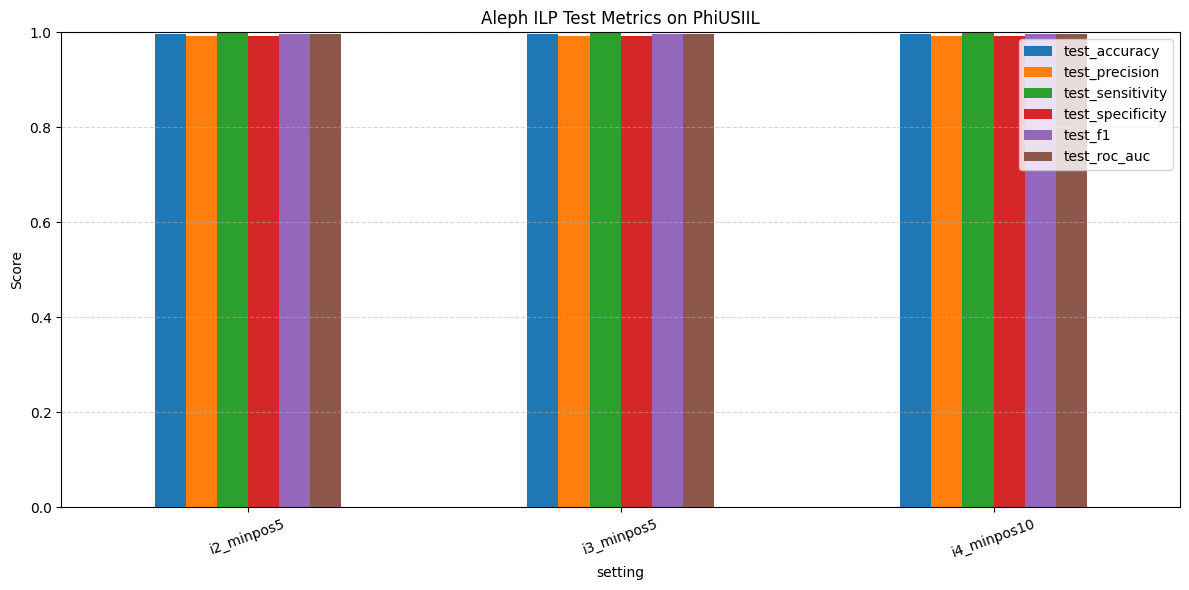

Saved plot to: C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\outputs\aleph_phiusiil\aleph_phiusiil_metric_comparison.png

Note on ROC-AUC:
Aleph produces hard logical predictions, not probability scores.
The ROC-AUC reported here is the hard-prediction ROC-AUC, equivalent to balanced accuracy: (sensitivity + specificity) / 2.

Report-ready summary
--------------------
Best setting:          i2_minpos5
Test accuracy:         0.997
Test precision:        0.993
Test sensitivity:      1.000
Test specificity:      0.993
Test F1:               0.997
Test ROC-AUC:          0.996
Number of rules:       4


In [13]:
# ==============================
# Cell 12: Plot and summarise results
# ==============================

metric_cols = [
    "test_accuracy",
    "test_precision",
    "test_sensitivity",
    "test_specificity",
    "test_f1",
    "test_roc_auc"
]

plot_df = results_df.set_index("setting")[metric_cols]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Aleph ILP Test Metrics on PhiUSIIL")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plot_path = OUTPUT_DIR / "aleph_phiusiil_metric_comparison.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print("Saved plot to:", plot_path)

print("\nNote on ROC-AUC:")
print("Aleph produces hard logical predictions, not probability scores.")
print("The ROC-AUC reported here is the hard-prediction ROC-AUC, equivalent to balanced accuracy: (sensitivity + specificity) / 2.")

if not valid_results.empty:
    row = best_row
    print("\nReport-ready summary")
    print("--------------------")
    print(f"Best setting:          {row['setting']}")
    print(f"Test accuracy:         {row['test_accuracy']:.3f}")
    print(f"Test precision:        {row['test_precision']:.3f}")
    print(f"Test sensitivity:      {row['test_sensitivity']:.3f}")
    print(f"Test specificity:      {row['test_specificity']:.3f}")
    print(f"Test F1:               {row['test_f1']:.3f}")
    print(f"Test ROC-AUC:          {row['test_roc_auc']:.3f}")
    print(f"Number of rules:       {int(row['n_rules'])}")

In [14]:
# ==============================
# Cell 13: Verify saved files for the comparison notebook
# ==============================

expected_files = [
    OUTPUT_DIR / "aleph_phiusiil_results.csv",
    OUTPUT_DIR / "aleph_phiusiil_best_rules.txt",
    OUTPUT_DIR / "aleph_phiusiil_metric_comparison.png",
    OUTPUT_DIR / "aleph_feature_scores.csv",
    OUTPUT_DIR / "aleph_discretisation_thresholds.csv",
    OUTPUT_DIR / "aleph_run_config.json",
]

print("Files saved for Aleph:")
for path in expected_files:
    print(path.exists(), path)

print("\nThe comparison notebook expects this file:")
print(BASE_DIR / "outputs" / "aleph_phiusiil" / "aleph_phiusiil_results.csv")

Files saved for Aleph:
True C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\outputs\aleph_phiusiil\aleph_phiusiil_results.csv
True C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\outputs\aleph_phiusiil\aleph_phiusiil_best_rules.txt
True C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\outputs\aleph_phiusiil\aleph_phiusiil_metric_comparison.png
True C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\outputs\aleph_phiusiil\aleph_feature_scores.csv
True C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member1_aleph_ilp\outputs\aleph_phiusiil\aleph_discretisation_thresholds.csv
True C:\Users\rahin\Documents\Masters Course\ML for 